In [1]:
import torch
from matplotlib import pyplot as plt
from whar_datasets.adapters.pytorch import PytorchAdapter
from whar_datasets.support.getter import WHARDatasetID, get_whar_cfg
from flow_matching.latent.training_ae_cond_time import CondAETimeTrainer
from flow_matching.whar.stft import istft_transform, plot_spectrogram_grid
from flow_matching.whar.models.ae_cond import CondSpectrogramAE
from flow_matching.whar.stft import decompress_stft

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
cfg = get_whar_cfg(WHARDatasetID.UCI_HAR)
cfg.subj_cross_val_split_groups
dataset = PytorchAdapter(cfg)

train_loader, val_loader, test_loader = dataset.get_dataloaders(
    train_batch_size=32, scv_group_index=0
)

num_classes = len(dataset.get_class_weights(train_loader))

Creating config hash...
Checking download...
Download exists.
Checking sessions...
Sessions exist.
Validating common format...
[########################################] | 100% Completed | 757.76 ms
Common format validated.
Checking windowing...
Loading config hash...
Windowing exists.
subject_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
activity_ids: [0 1 2 3 4 5]
train: 7201 | val: 801 | test: 1497
Postprocessing...


Loading windows: 100%|██████████| 9499/9499 [00:07<00:00, 1281.32it/s]


Getting normalization parameters...
Loading config hash...
Creating normalization parameters hash...
Loading normalization parameters hash...


Loading samples: 100%|██████████| 9499/9499 [00:02<00:00, 4302.22it/s]


In [4]:
ae = CondSpectrogramAE(latent_channels=24)
trainer = CondAETimeTrainer(
    model=ae,
    train_loader=train_loader,
    val_loader=val_loader,
    eta=(1 / num_classes),
    null_class=num_classes,
    track=True,
)

In [5]:
trainer.train(num_epochs=30, device=device, lr=1e-3)

Training model with size: 7.900 MiB


  0%|          | 0/226 [00:00<?, ?it/s]/Users/maxburzer/flow-matching/.venv/lib/python3.11/site-packages/torch/functional.py:730: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::stft. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:84.)
  return _VF.stft(  # type: ignore[attr-defined]
/Users/maxburzer/flow-matching/src/flow_matching/whar/stft.py:33: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::istft. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:84.)
  waveform = torch.istft(
100%|██████████| 1/1 [00:01<00:00,  1.21s/it]


Loss: 0.998, MSE: 920522.938, MAE: 576676.250


100%|██████████| 1/1 [00:00<00:00,  1.13it/s]


Loss: 0.981, MSE: 905006.625, MAE: 571501.438


...

Loss: 0.969, MSE: 893987.250, MAE: 567324.062


100%|██████████| 1/1 [00:00<00:00,  1.08it/s]


Loss: 0.967, MSE: 892711.625, MAE: 567343.750


100%|██████████| 1/1 [00:00<00:00,  1.02it/s]

Loss: 0.968, MSE: 893176.250, MAE: 567679.000


In [ ]:
torch.save(ae.state_dict(), f"cond_ae_{ae.latent_channels}_time.pt")

In [ ]:
ae.load_state_dict(torch.load(f"cond_ae_{ae.latent_channels}_time.pt"))

<All keys matched successfully>

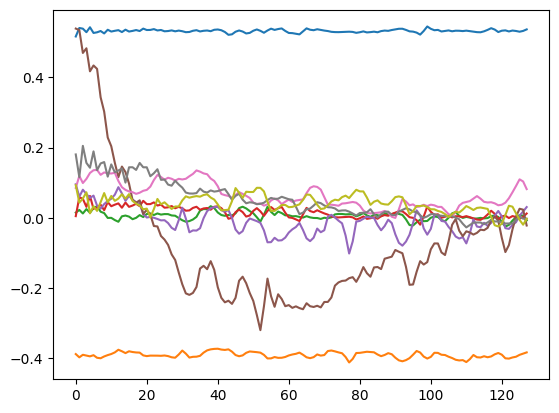

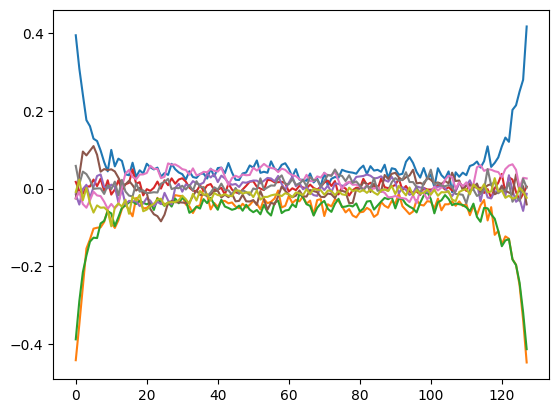

In [6]:
y, x = next(iter(test_loader))
recon, _ = ae(x.to(device), y.to(device))

plt.plot(x.squeeze(0).detach().cpu().numpy())
plt.show()

plt.plot(recon.squeeze(0).detach().cpu().numpy())
plt.show()